In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_customer = pd.read_csv('./data/cleaned_customer.csv', parse_dates=['InvoiceDate'])

In [3]:
data_customer

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,GMV
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
802627,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
802628,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
802629,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
802630,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [4]:
reference_date = data_customer['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"分析参考日期: {reference_date}")

分析参考日期: 2011-12-10 12:50:00


In [12]:
rfm = data_customer.groupby('Customer ID').agg(
    R=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    F=('Invoice', 'nunique'),
    M=('GMV', 'sum')
)

In [13]:
r_threshold = rfm['R'].median()
f_threshold = rfm['F'].median()
m_threshold = rfm['M'].median()

print(f"R 中位数: {r_threshold} 天")
print(f"F 中位数: {f_threshold} 次")
print(f"M 中位数: £{m_threshold:.2f}")

# 打分:1=高,0=低
rfm['R_score'] = (rfm['R'] <= r_threshold).astype(int)   # ⚠ R 是反向
rfm['F_score'] = (rfm['F'] >= f_threshold).astype(int)
rfm['M_score'] = (rfm['M'] >= m_threshold).astype(int)

R 中位数: 95.0 天
F 中位数: 3.0 次
M 中位数: £880.38


In [14]:
# 把 R/F/M 三个 0/1 拼成一个 3 位字符串,比如 "111"、"010"
rfm['RFM_score'] = (rfm['R_score'].astype(str) + 
                    rfm['F_score'].astype(str) + 
                    rfm['M_score'].astype(str))

# 映射到 8 类客户
segment_map = {
    '111': '重要价值客户',
    '101': '重要发展客户',
    '011': '重要保持客户',
    '001': '重要挽留客户',
    '110': '一般价值客户',
    '100': '一般发展客户',
    '010': '一般保持客户',
    '000': '一般挽留客户'
}
rfm['Segment'] = rfm['RFM_score'].map(segment_map)

print(rfm['Segment'].value_counts())

Segment
重要价值客户    1889
一般挽留客户    1667
重要保持客户     750
一般发展客户     609
一般保持客户     331
一般价值客户     319
重要挽留客户     174
重要发展客户     113
Name: count, dtype: int64


In [16]:
rfm

,R,F,M,R_score,F_score,M_score,RFM_score,Segment
Customer ID,,,,,,,,
12346.0,326,3,77352.96,0,1,1,011,重要保持客户
12347.0,2,8,5633.32,1,1,1,111,重要价值客户
12348.0,75,5,1658.40,1,1,1,111,重要价值客户
12349.0,19,3,3678.69,1,1,1,111,重要价值客户
12350.0,310,1,294.40,0,0,0,000,一般挽留客户
...,...,...,...,...,...,...,...,...
18283.0,4,22,2730.70,1,1,1,111,重要价值客户
18284.0,432,1,411.68,0,0,0,000,一般挽留客户
18285.0,661,1,377.00,0,0,0,000,一般挽留客户


In [19]:
segment_summary = rfm.groupby('Segment').agg(
    客户数=('M', 'count'),
    总消费=('M', 'sum'),
    人均消费=('M', 'mean'),
    平均频次=('F', 'mean'),
    平均最近天数=('R', 'mean')
).round(2)

# 加上占比
segment_summary['客户占比'] = (segment_summary['客户数'] / segment_summary['客户数'].sum() * 100).round(1)
segment_summary['GMV占比'] = (segment_summary['总消费'] / segment_summary['总消费'].sum() * 100).round(1)
segment_summary = segment_summary.sort_values('总消费', ascending=False)

In [18]:
segment_summary

,客户数,总消费,人均消费,平均频次,平均最近天数,客户占比,GMV占比
Segment,,,,,,,
重要价值客户,1889,13361316.08,7073.22,13.51,29.46,32.3,76.6
重要保持客户,750,2304828.21,3073.10,6.78,271.05,12.8,13.2
一般挽留客户,1667,515321.54,309.13,1.29,421.31,28.5,3.0
重要发展客户,113,342362.28,3029.75,1.79,40.95,1.9,2.0
重要挽留客户,174,298650.50,1716.38,1.61,384.17,3.0,1.7
一般发展客户,609,226411.02,371.78,1.43,40.85,10.4,1.3
一般保持客户,331,193056.77,583.25,3.83,311.60,5.7,1.1
一般价值客户,319,192503.58,603.46,3.82,33.84,5.5,1.1


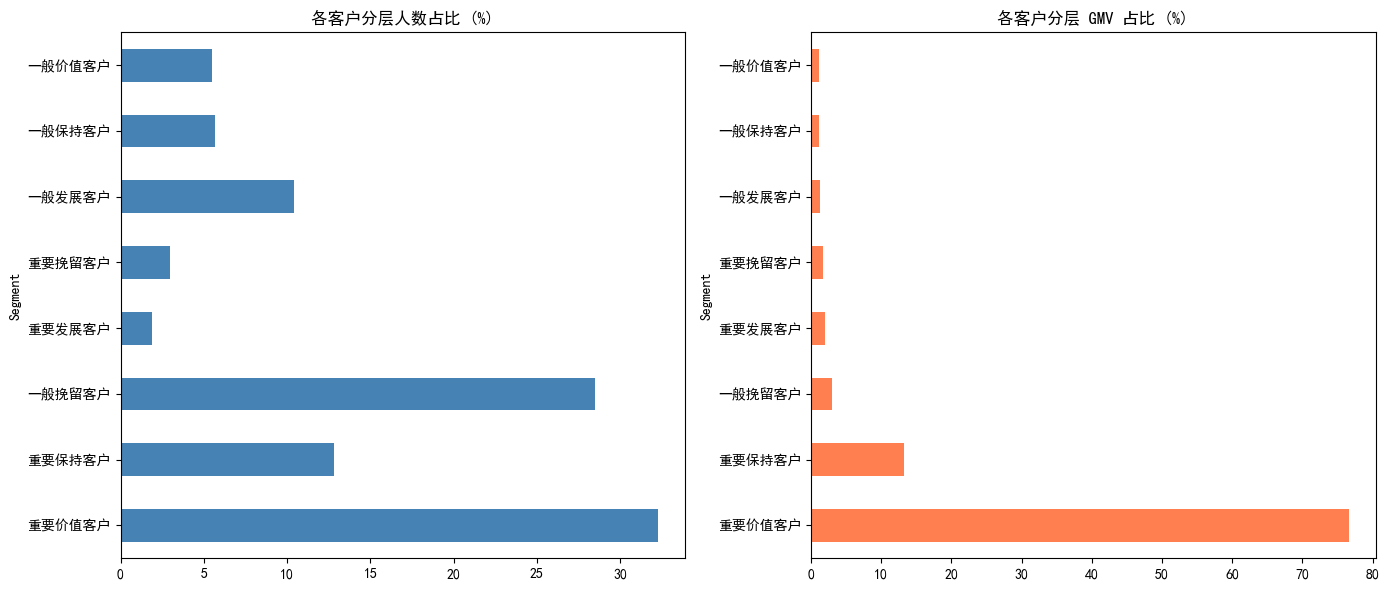

In [22]:
plt.rcParams['font.family'] = 'SimHei'
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
segment_summary['客户占比'].plot(kind='barh', ax=ax[0], color='steelblue')
ax[0].set_title('各客户分层人数占比 (%)')
segment_summary['GMV占比'].plot(kind='barh', ax=ax[1], color='coral')
ax[1].set_title('各客户分层 GMV 占比 (%)')
plt.tight_layout()
plt.show()

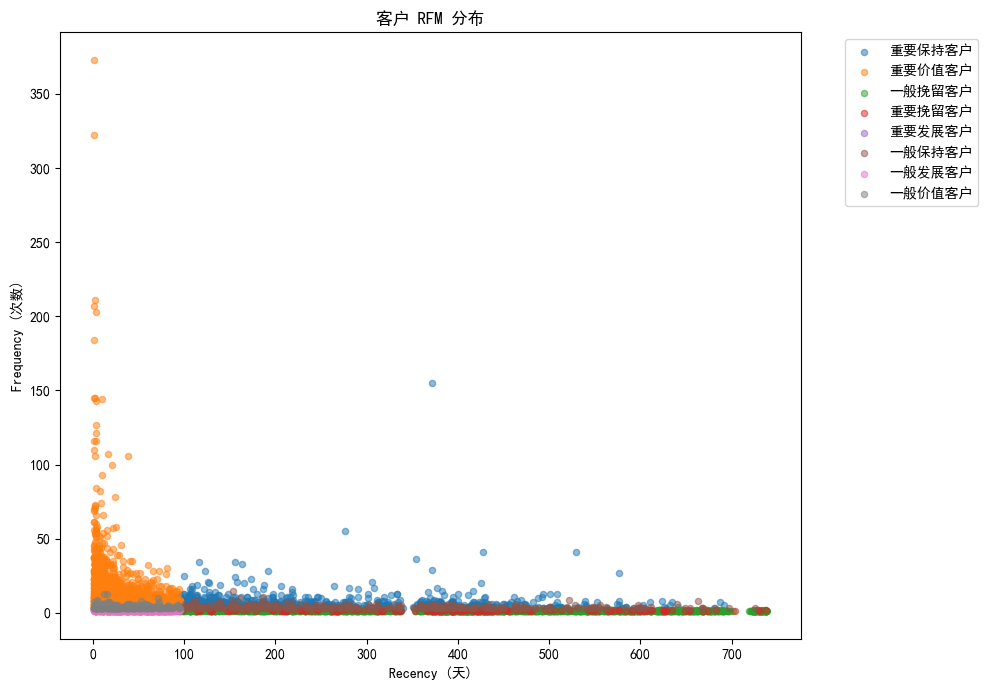

In [23]:
plt.figure(figsize=(10, 7))
for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['R'], subset['F'], label=segment, alpha=0.5, s=20)
plt.xlabel('Recency (天)')
plt.ylabel('Frequency (次数)')
plt.title('客户 RFM 分布')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()